Autor: @Rodrigo de Barros

Descrição: 
Com base no tamanho de cada amostra de sedimentos marinhos, é possível estimar a velocidade de fluxo da corrente de fundo naquele local, no determinado período. Os dados, após sua análise, foram interpolados e analisados 

Etapas do processo:
- Importação de Pacotes
- Importação dos dados
- Visualização dos dados
- Interpolação dos dados
- Análise de tendências com base na divisão temporal selecionada à partir de bibliografia
- Análise de ciclos

## Importação de pacotes:

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from scipy.interpolate import interp1d
import numpy as np

## Importação dos dados 

In [3]:
file = 'FINAL_FINAL_FINAL.csv'

In [4]:
df = pd.read_csv(file, sep=";")

In [5]:
df

,777_age,777_flow,778_age,778_flow,779_age,779_flow,780_age,780_flow
0,567,24.326934,2160.0,17.994951,1420.0,18.151057,1310.0,22.148790
1,644,21.202023,3024.0,20.672340,1752.0,20.536750,1552.0,24.251891
2,721,25.884599,3889.0,20.999796,2085.0,22.759246,1793.0,25.083472
3,798,22.861445,4753.0,23.826473,2417.0,16.292105,2035.0,24.888654
4,875,25.046538,5617.0,20.538251,2749.0,19.256007,2276.0,25.422294
...,...,...,...,...,...,...,...,...
276,14060,38.608980,NaN,NaN,NaN,NaN,NaN,NaN
277,14086,39.040242,NaN,NaN,NaN,NaN,NaN,NaN
278,14112,31.394236,NaN,NaN,NaN,NaN,NaN,NaN
279,14138,37.141032,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
idade_777 = df['777_age']
velo_777 = df['777_flow']
idade_778 = df['778_age']
velo_778 = df['778_flow']
idade_779 = df['779_age']
velo_779 = df['779_flow']
idade_780 = df['780_age']
velo_780 = df['780_flow']

In [7]:
idade_777

0        567
1        644
2        721
3        798
4        875
       ...  
276    14060
277    14086
278    14112
279    14138
280    14164
Name: 777_age, Length: 281, dtype: int64

## Visualização dos Dados

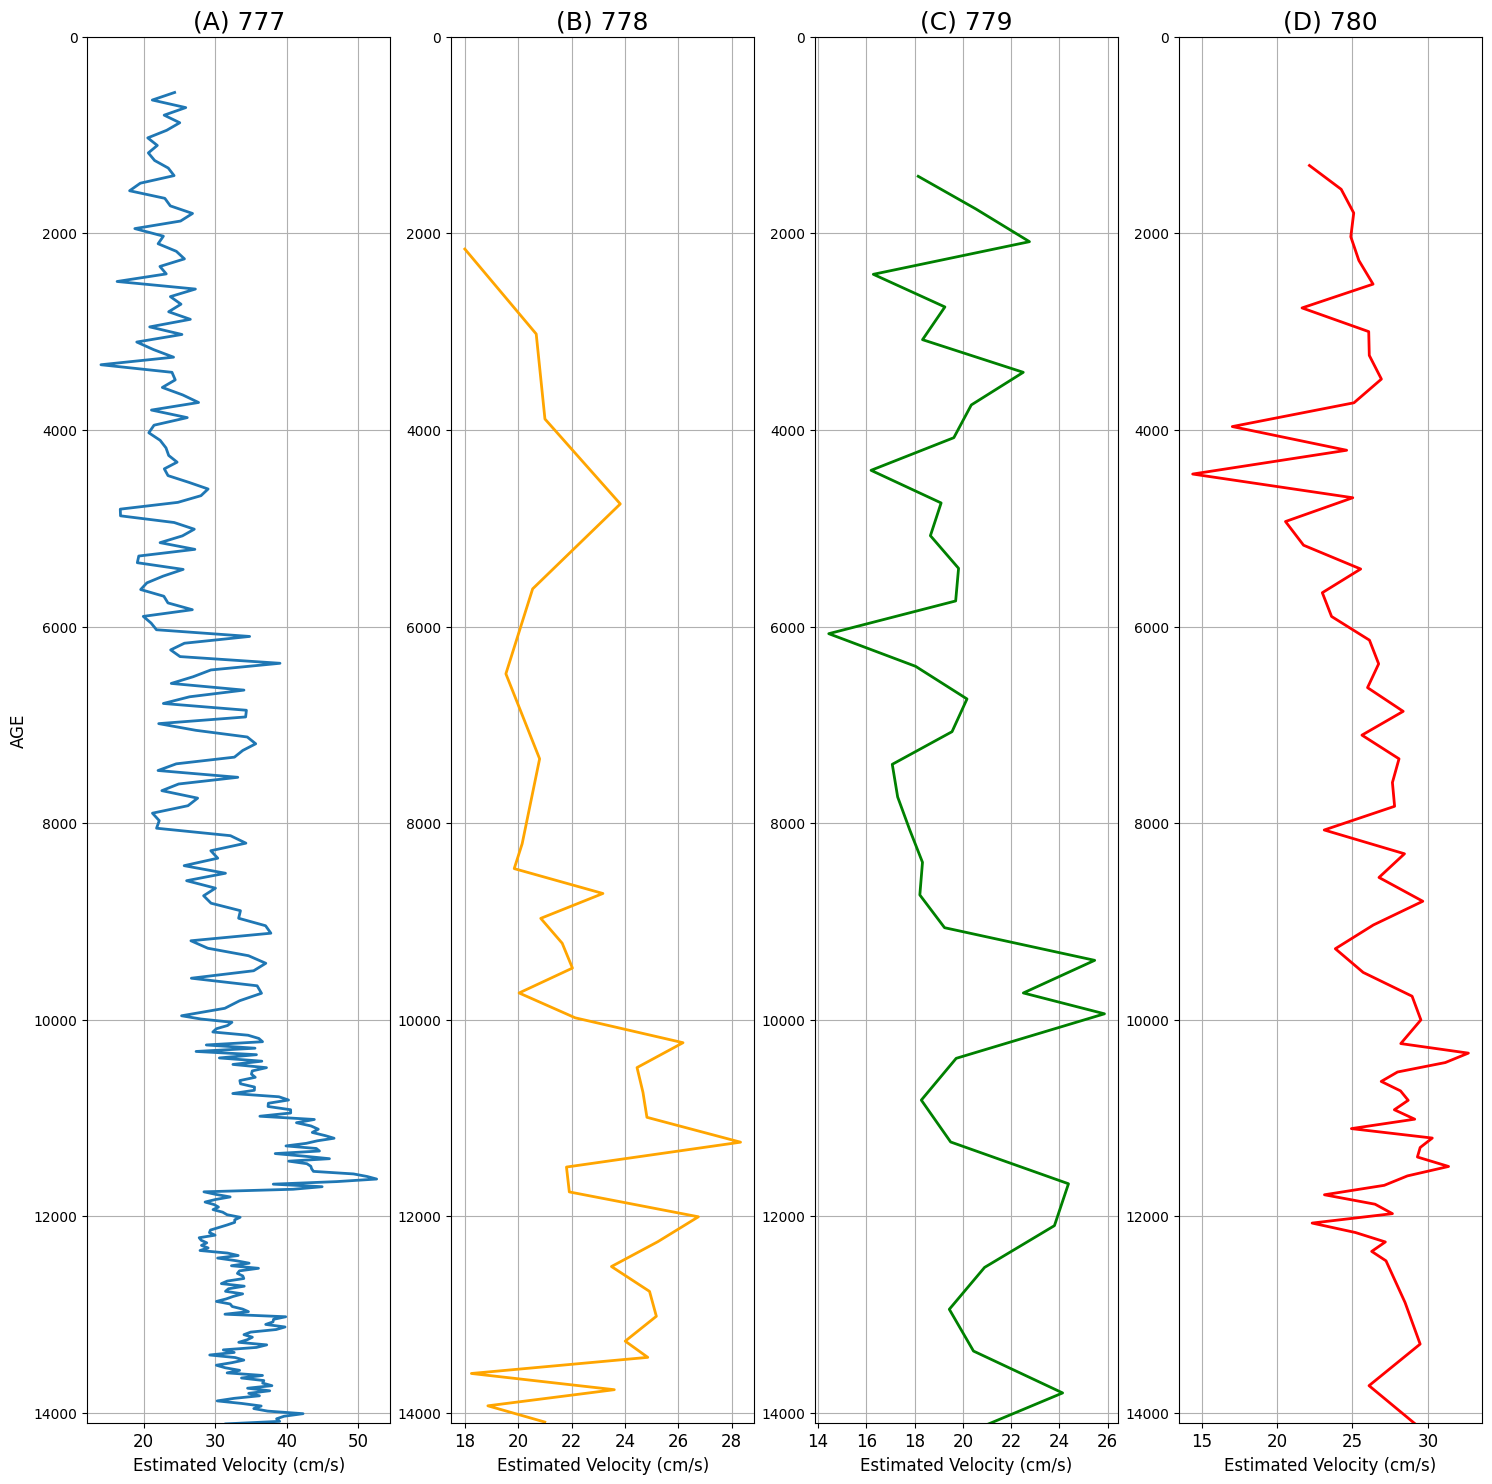

In [8]:
plt.figure(figsize=(18,18))

plt.subplot(1,4,1)
plt.plot(velo_777, idade_777, linewidth=2)
plt.ylim(0, 14100)
plt.gca().invert_yaxis()
plt.grid()
plt.title('(A) 777', fontsize=18)
plt.ylabel('AGE', fontsize=12)
plt.xlabel('Estimated Velocity (cm/s)', fontsize=12)
plt.xticks(fontsize=12)

plt.subplot(1,4,2)
plt.plot(velo_778, idade_778, color='orange', linewidth=2)
plt.ylim(0, 14100)
plt.gca().invert_yaxis()
plt.grid()
plt.title('(B) 778', fontsize=18)
plt.xlabel('Estimated Velocity (cm/s)', fontsize=12)
plt.xticks(fontsize=12)

plt.subplot(1,4,3)
plt.plot(velo_779, idade_779, color='green', linewidth=2)
plt.ylim(0, 14100)
plt.gca().invert_yaxis()
plt.grid()
plt.title('(C) 779', fontsize=18)
plt.xlabel('Estimated Velocity (cm/s)', fontsize=12)
plt.xticks(fontsize=12)

plt.subplot(1,4,4)
plt.plot(velo_780, idade_780, color='r', linewidth=2)
plt.ylim(0, 14100)
plt.gca().invert_yaxis()
plt.grid()
plt.title('(D) 780', fontsize=18)
plt.xlabel('Estimated Velocity (cm/s)', fontsize=12)
plt.xticks(fontsize=12)

plt.savefig('ENGLISH_CORES.png')
plt.show()

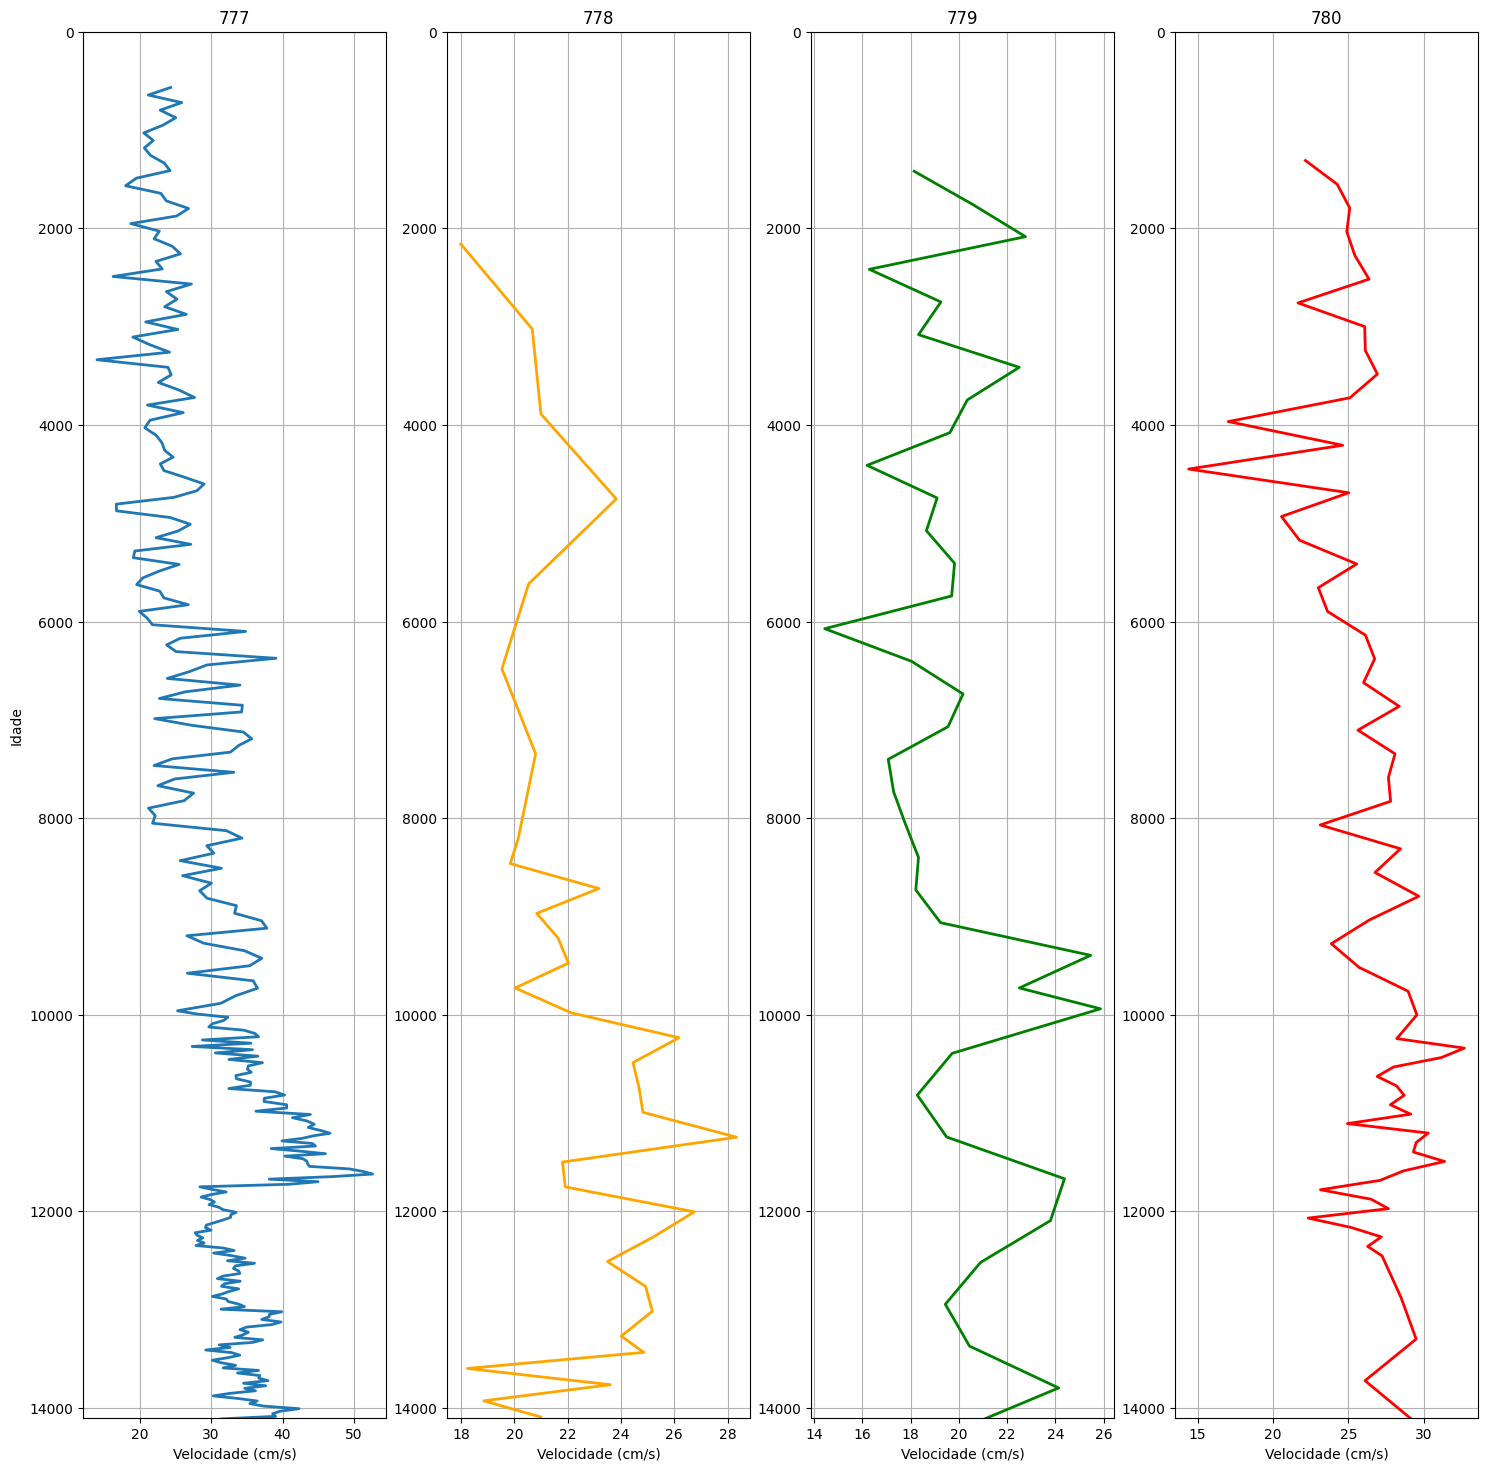

In [14]:
plt.figure(figsize=(18,18))


plt.subplot(1,4,1)
plt.plot(velo_777,idade_777, linewidth=2)
plt.ylim(0, 14100)
plt.gca().invert_yaxis()
plt.grid()
plt.title('777')
plt.ylabel('Idade')
plt.xlabel('Velocidade (cm/s)')

plt.subplot(1,4,2)
plt.plot(velo_778,idade_778, color ='orange', linewidth=2)
plt.ylim(0, 14100)
plt.gca().invert_yaxis()
plt.grid()
plt.xlabel('Velocidade (cm/s)')
plt.title('778')


plt.subplot(1,4,3)
plt.plot(velo_779,idade_779, color ='green', linewidth=2)
plt.ylim(0, 14100)
plt.gca().invert_yaxis()
plt.grid()
plt.xlabel('Velocidade (cm/s)')
plt.title('779')


plt.subplot(1,4,4)
plt.plot(velo_780,idade_780, color ='r', linewidth=2)
plt.ylim(0, 14100)
plt.gca().invert_yaxis()
plt.grid()
plt.xlabel('Velocidade (cm/s)')
plt.title('780')

plt.savefig('TESTEMUNHOS_FIGURA BASE.png')
plt.show()

## Interpolação dos dados

In [9]:
velo_777_norm = velo_777 - np.mean(velo_777)
velo_778_norm = velo_778 - np.mean(velo_778)
velo_779_norm = velo_779 - np.mean(velo_779)
velo_780_norm = velo_780 - np.mean(velo_780)

In [10]:
import numpy as np

# eixo comum de idade
y_common = np.linspace(
    max(min(idade_777), min(idade_778), min(idade_779), min(idade_780)),
    min(max(idade_777), max(idade_778), max(idade_779), max(idade_780)),
    1000
)

# interpolação das velocidades normalizadas
v777_interp = np.interp(y_common, idade_777, velo_777_norm)
v778_interp = np.interp(y_common, idade_778, velo_778_norm)
v779_interp = np.interp(y_common, idade_779, velo_779_norm)
v780_interp = np.interp(y_common, idade_780, velo_780_norm)

# média
velo_mean_norm = np.mean([
    v777_interp,
    v778_interp,
    v779_interp,
    v780_interp
], axis=0)

## Análise de tendências com base na divisão temporal selecionada à partir de bibliografia

In [11]:
import numpy as np
import pandas as pd

intervalos = [
    (14000, 12700),
    (12700, 11500),
    (11500, 10000),
    (10000, 8000),
    (8000, 6000),
    (6000, 4000),
    (4000, 2000)
]

rows = []

for a, b in intervalos:
    # pega índices mais próximos no eixo comum
    idx_a = np.argmin(np.abs(y_common - a))
    idx_b = np.argmin(np.abs(y_common - b))

    va = velo_mean_norm[idx_a]
    vb = velo_mean_norm[idx_b]

    # variação absoluta (cm/s)
    delta = vb - va

    # variação relativa (%)
    delta_rel = (delta / va * 100) if va != 0 else np.nan

    direction = "↑ aumentou" if delta > 0 else "↓ diminuiu" if delta < 0 else "→ estável"

    rows.append([
        f"{a} → {b}",
        va,
        vb,
        delta,
        delta_rel,
        direction
    ])

df = pd.DataFrame(rows, columns=[
    "Intervalo (anos)",
    "Velocidade inicial (cm/s)",
    "Velocidade final (cm/s)",
    "Variação (cm/s)",
    "Variação (%)",
    "Tendência"
])

print("\n📊 VARIAÇÃO POR INTERVALO\n")
print(df.to_string(index=False))


📊 VARIAÇÃO POR INTERVALO

Intervalo (anos)  Velocidade inicial (cm/s)  Velocidade final (cm/s)  Variação (cm/s)  Variação (%)  Tendência
   14000 → 12700                   2.701388                 1.311704        -1.389684    -51.443345 ↓ diminuiu
   12700 → 11500                   1.311704                 4.786747         3.475044    264.925977 ↑ aumentou
   11500 → 10000                   4.786747                 1.424399        -3.362348    -70.242860 ↓ diminuiu
    10000 → 8000                   1.424399                -3.795327        -5.219726   -366.451093 ↓ diminuiu
     8000 → 6000                  -3.795327                -4.482321        -0.686993     18.101034 ↓ diminuiu
     6000 → 4000                  -4.482321                -4.862284        -0.379964      8.476941 ↓ diminuiu
     4000 → 2000                  -4.862284                -2.857948         2.004336    -41.222113 ↑ aumentou


In [19]:
import numpy as np
import pandas as pd

intervalos = [
    (14000, 12700),
    (12700, 11500),
    (11500, 10000),
    (10000, 8000),
    (8000, 6000),
    (6000, 4000),
    (4000, 2000)
]

rows = []

for a, b in intervalos:
    # pega valores nos pontos mais próximos
    idx_a = np.argmin(np.abs(y_common - a))
    idx_b = np.argmin(np.abs(y_common - b))

    va = velo_mean_norm[idx_a]
    vb = velo_mean_norm[idx_b]

    delta = vb - va
    delta_rel = delta / va if va != 0 else np.nan

    direction = "↑ aumentou" if delta > 0 else "↓ diminuiu" if delta < 0 else "→ estável"

    rows.append([f"{a} → {b}", va, vb, delta, delta_rel, direction])

df = pd.DataFrame(rows, columns=[
    "Intervalo",
    "Valor inicial",
    "Valor final",
    "Δ absoluto",
    "Δ relativo",
    "Tendência"
])

print("\n📊 VARIAÇÃO POR INTERVALO\n")
print(df.to_string(index=False))


📊 VARIAÇÃO POR INTERVALO

    Intervalo  Valor inicial  Valor final  Δ absoluto  Δ relativo  Tendência
14000 → 12700       2.701388     1.311704   -1.389684   -0.514433 ↓ diminuiu
12700 → 11500       1.311704     4.786747    3.475044    2.649260 ↑ aumentou
11500 → 10000       4.786747     1.424399   -3.362348   -0.702429 ↓ diminuiu
 10000 → 8000       1.424399    -3.795327   -5.219726   -3.664511 ↓ diminuiu
  8000 → 6000      -3.795327    -4.482321   -0.686993    0.181010 ↓ diminuiu
  6000 → 4000      -4.482321    -4.862284   -0.379964    0.084769 ↓ diminuiu
  4000 → 2000      -4.862284    -2.857948    2.004336   -0.412221 ↑ aumentou


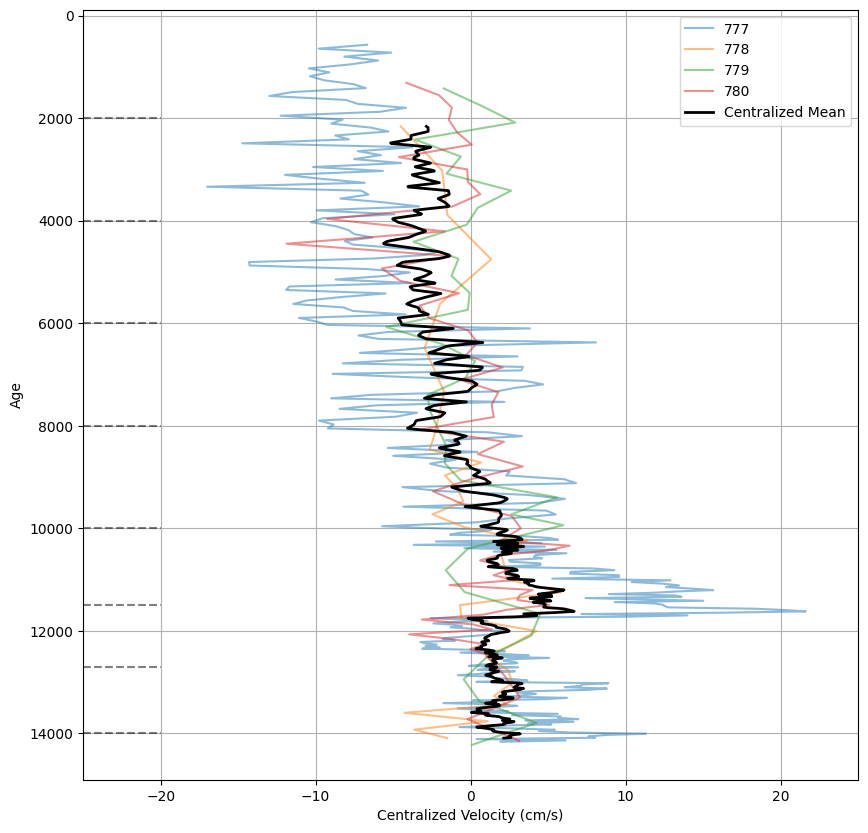

In [12]:
idades_datacao = [2000, 4000, 6000, 8000, 10000, 11500, 12700, 14000]

# Plot
plt.figure(figsize=(10,10))
plt.plot(velo_777_norm, idade_777, alpha=0.5, label='777')
plt.plot(velo_778_norm, idade_778, alpha=0.5, label='778')
plt.plot(velo_779_norm, idade_779, alpha=0.5, label='779')
plt.plot(velo_780_norm, idade_780, alpha=0.5, label='780')
plt.plot(velo_mean_norm, y_common, color='black', linewidth=2, label='Centralized Mean')
plt.gca().invert_yaxis()

for i, datacao in enumerate(idades_datacao):
    plt.hlines(y=datacao, xmin=-25, xmax=-20, color='black', linestyle='--', alpha=0.5)
    # Coloca o texto na borda esquerda, levemente deslocado-20

plt.xlabel('Centralized Velocity (cm/s)')
plt.ylabel('Age')
plt.xlim(-25, 25)
plt.grid()
plt.legend(loc='upper right')
plt.savefig('ENGLISH_CENTRALIZD_MEAN.png')
plt.show()

## Análise dos Ciclos

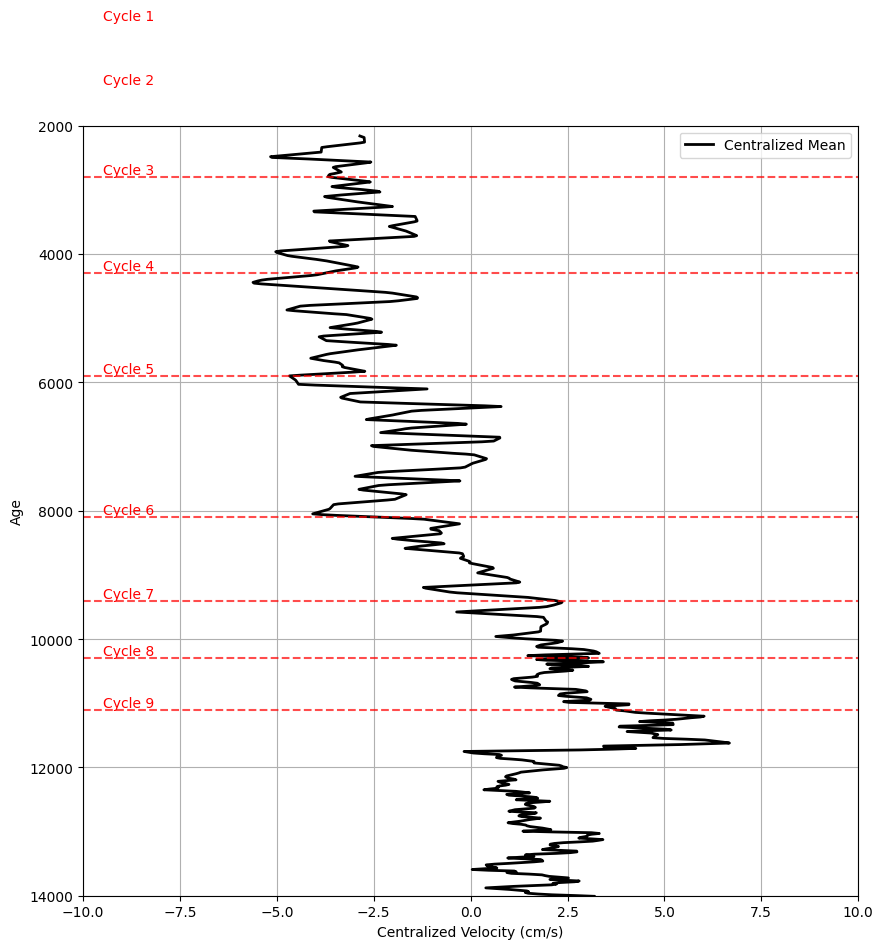

In [15]:
import matplotlib.pyplot as plt

bond_ciclos = [400, 1400, 2800, 4300, 5900, 8100, 9400, 10300, 11100]

plt.figure(figsize=(10,10))
plt.plot(velo_mean_norm, y_common, color='black', linewidth=2, label='Centralized Mean')

# Descobre o mínimo do eixo x
x_min, x_max = -10, 10 
for i, ciclo in enumerate(bond_ciclos):
    plt.axhline(ciclo, color='red', linestyle='--', alpha=0.7)
    # Coloca o texto na borda esquerda, levemente deslocado
    plt.text(x_min + 0.5, ciclo, f'Cycle {i+1}', color='red', fontsize=10, verticalalignment='bottom')

plt.gca().invert_yaxis()
plt.xlabel('Centralized Velocity (cm/s)')
plt.ylabel('Age')
plt.grid()
plt.xlim(x_min, x_max)
plt.ylim(14000, 2000)
plt.legend()

plt.savefig('ENGLISH_BOND.png')
plt.show()

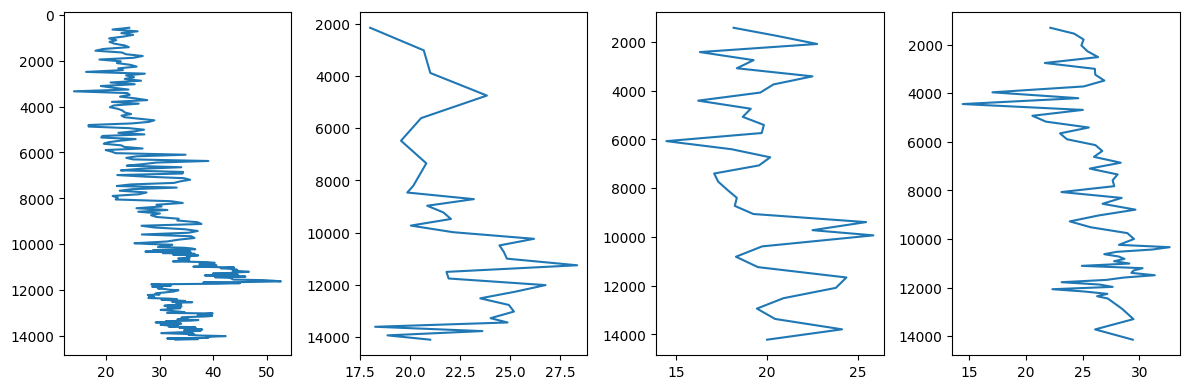

In [46]:
fig, axs = plt.subplots(1, 4, figsize=(12,4))

axs[0].plot(velo_777, idade_777)
axs[1].plot(velo_778, idade_778)
axs[2].plot(velo_779, idade_779)
axs[3].plot(velo_780, idade_780)

for ax in axs:
    ax.invert_yaxis()
    ax.grid()

plt.tight_layout()
plt.show()

Períodos dominantes (unidades de idade por ciclo):
[1992.82 1328.55  854.07  362.33]


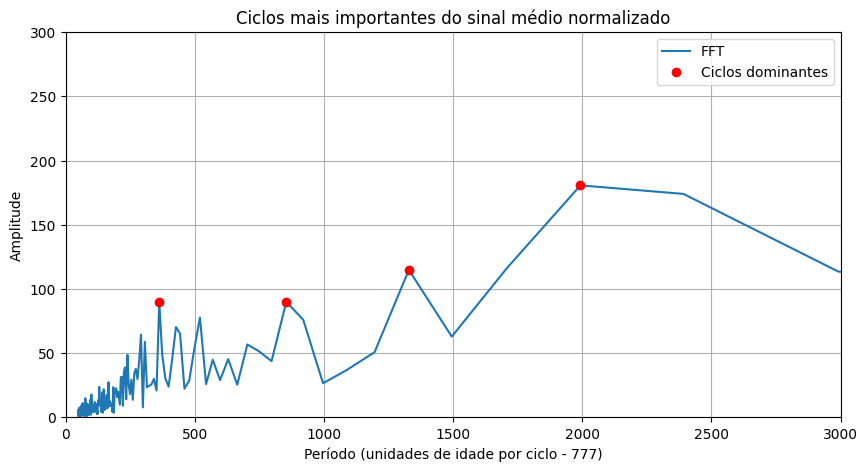

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# --- Sinal ---
sinal = velo_mean_norm - np.mean(velo_mean_norm)  # remove média

# --- FFT ---
dy = y_common[1] - y_common[0] # espaçamento uniforme no eixo idade
fft_vals = np.fft.fft(sinal)
freqs = np.fft.fftfreq(len(sinal), d=dy)

# Frequências positivas
mask = freqs > 0
freqs_pos = freqs[mask]
fft_pos = np.abs(fft_vals[mask])

# --- Converter frequência em período ---
periods = 1 / freqs_pos

# --- Detectar picos dominantes ---
peaks, _ = find_peaks(fft_pos, height=max(fft_pos)*0.1)  # filtra picos fracos
ciclos_dominantes = periods[peaks]

print("Períodos dominantes (unidades de idade por ciclo):")
print(np.round(ciclos_dominantes, 2))

# --- Plotar ---
plt.figure(figsize=(10,5))
plt.plot(periods, fft_pos, label="FFT")
plt.plot(ciclos_dominantes, fft_pos[peaks], "ro", label="Ciclos dominantes")
plt.xlabel("Período (unidades de idade por ciclo - 777)")
plt.ylabel("Amplitude")
plt.ylim(0, 300)
plt.title("Ciclos mais importantes do sinal médio normalizado")
plt.xlim(0, 3000)  # opcional: limitar períodos muito longos
plt.grid()
plt.legend()
plt.show()

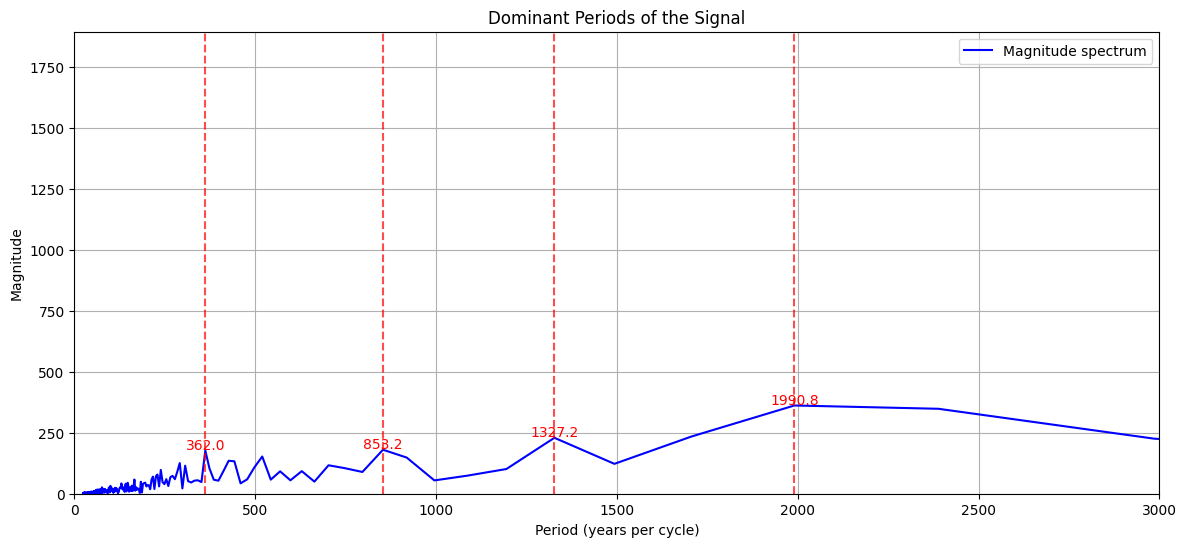

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# --- Sinal (exemplo: seu sinal normalizado) ---
sinal = velo_mean_norm - np.mean(velo_mean_norm)

# --- FFT ---
dy = y_common[1] - y_common[0]  # espaçamento uniforme no eixo idade
fft_vals = np.fft.fft(sinal)
freqs = np.fft.fftfreq(len(sinal), d=dy)

# Frequências positivas
mask = freqs > 0
freqs_pos = freqs[mask]
fft_pos = np.abs(fft_vals[mask])

# Converter frequência em período
periods = 1 / freqs_pos
# Detect dominant peaks
peaks, _ = find_peaks(fft_pos, height=max(fft_pos)*0.1)
dominant_cycles = periods[peaks]

# --- Plot ---
plt.figure(figsize=(14,6))

plt.plot(periods,
         fft_pos,
         label="Magnitude spectrum",
         color='blue')

# Vertical lines at dominant peaks
for i, cycle in enumerate(dominant_cycles):
    plt.axvline(cycle,
                color='red',
                linestyle='--',
                alpha=0.7)

    plt.text(cycle,
             fft_pos[peaks][i] + 5,
             f"{cycle:.1f}",
             ha='center',
             color='red')

plt.xlabel("Period (years per cycle)")
plt.ylabel("Magnitude")
plt.title("Dominant Periods of the Signal")

plt.xlim(0, 3000)
plt.ylim(0, max(fft_pos) * 1.2)

plt.grid(True)
plt.legend()

plt.savefig("ENGLISH_FOURIER")
plt.show()